## The Kaggle House_Prices Regression Problem
### Predicting Sales Prices 

### 1. Data Loading

In [1]:
# importing dependencies

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder


from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,VotingRegressor
from xgboost import XGBRegressor
from sklearn.kernel_ridge import KernelRidge



In [2]:
# reading csv file
train_df = pd.read_csv(r'C:\Users\deoff\Documents\Vs_code files\House Prices\train.csv')
test_df = pd.read_csv(r'C:\Users\deoff\Documents\Vs_code files\House Prices\test.csv')


In [3]:
# visualizing the first five instances of the dataset
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 2. Data Exploration

In [4]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# there are 43 categorical features and 38 numerical features
train_df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

##### Here, the 38 numerical columns are separated inorder to begin outlier detection

In [6]:
num_columns = train_df.dtypes[train_df.dtypes != "str"].index
train_df.dtypes[train_df.dtypes != "str"]

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

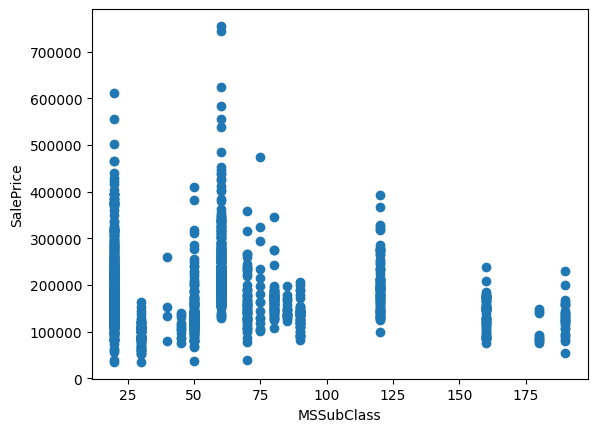

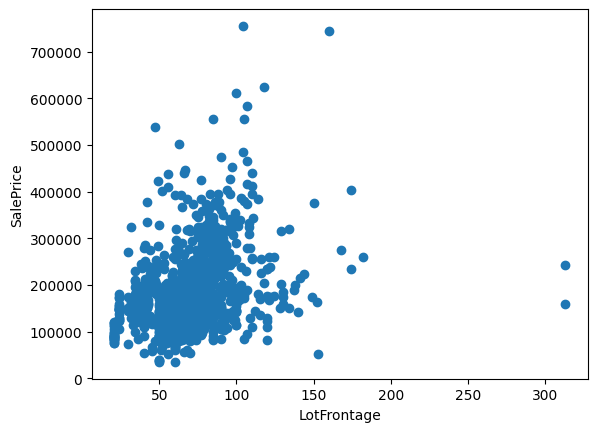

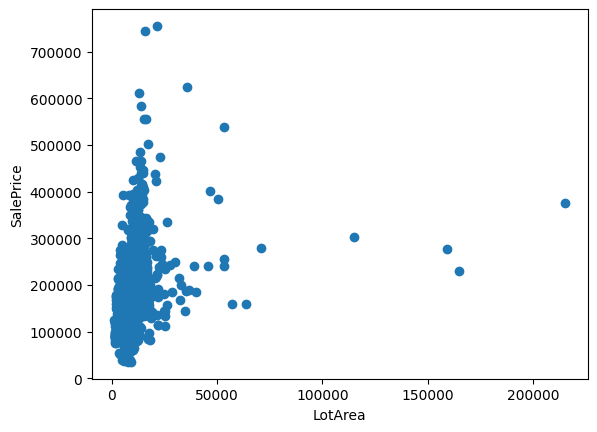

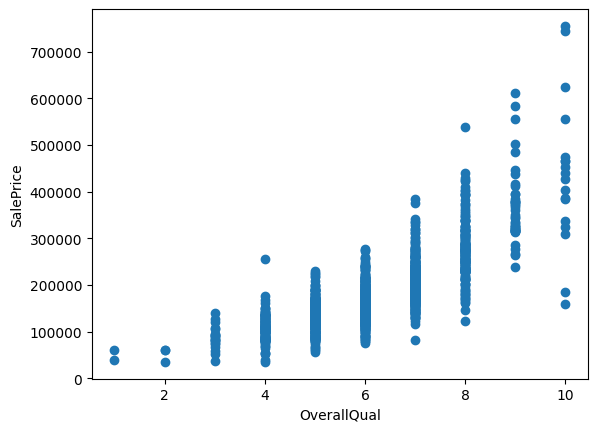

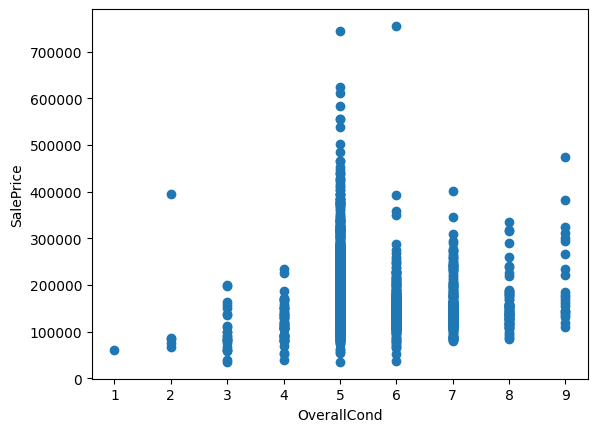

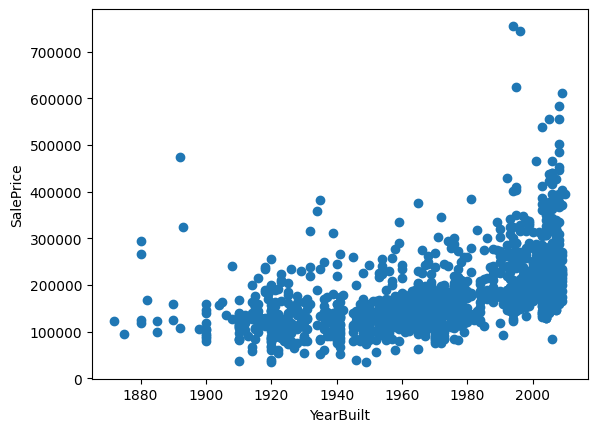

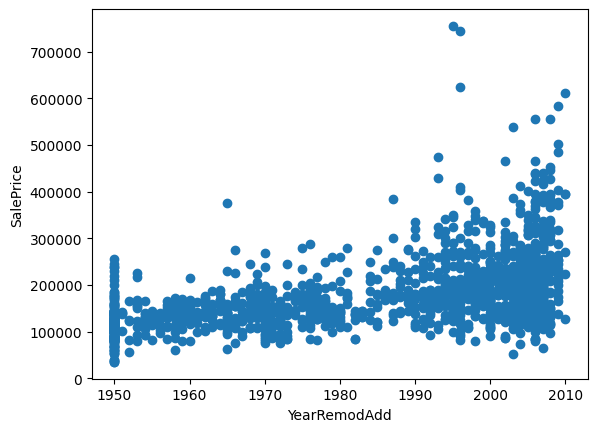

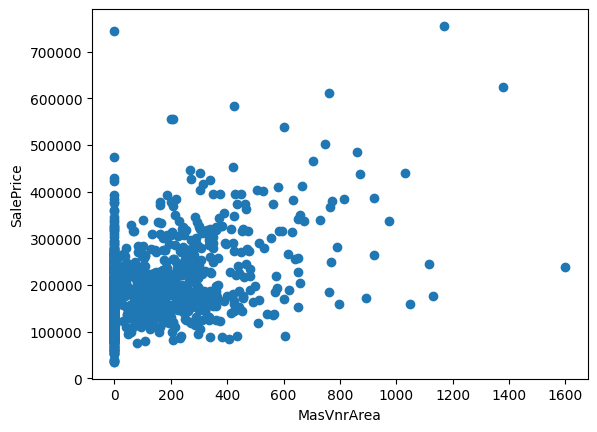

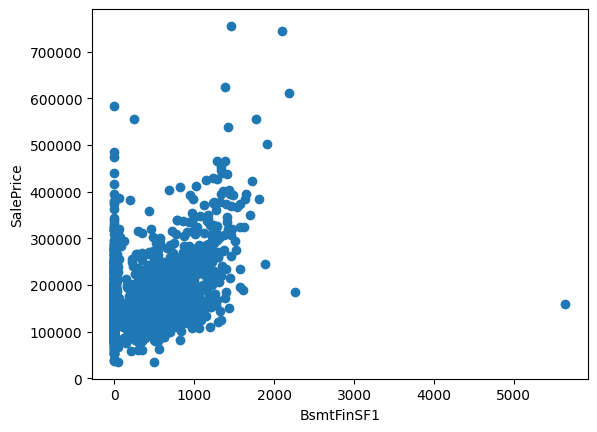

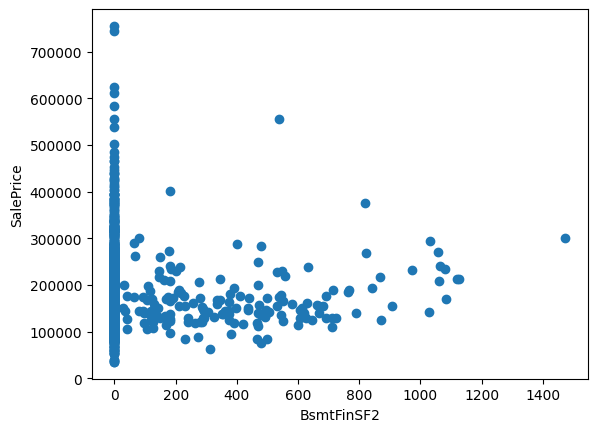

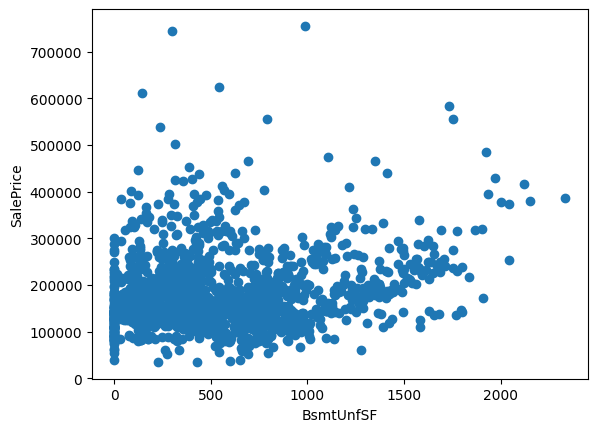

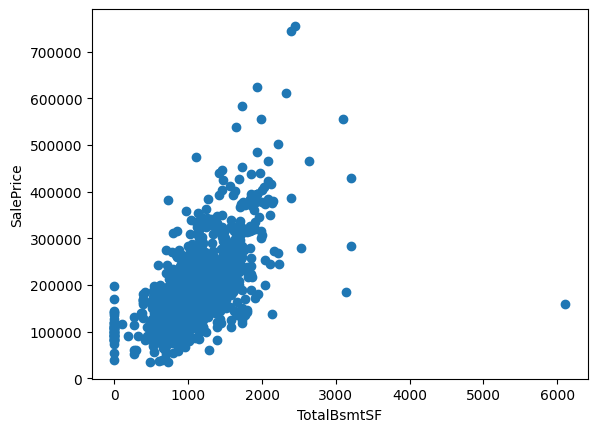

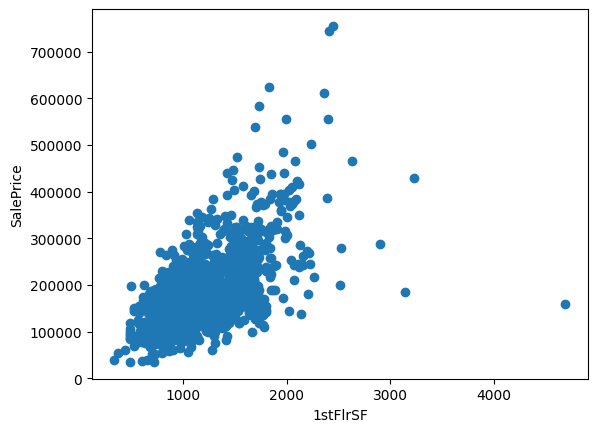

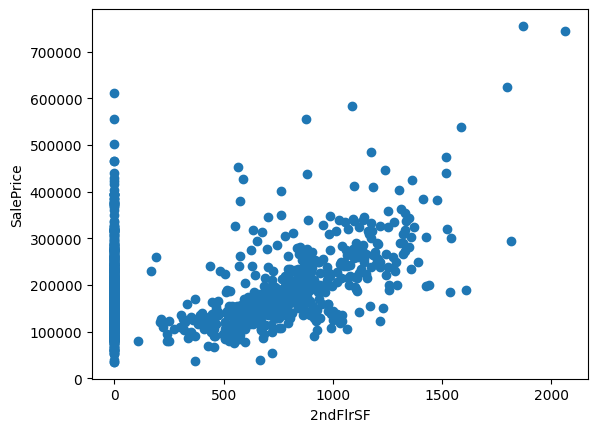

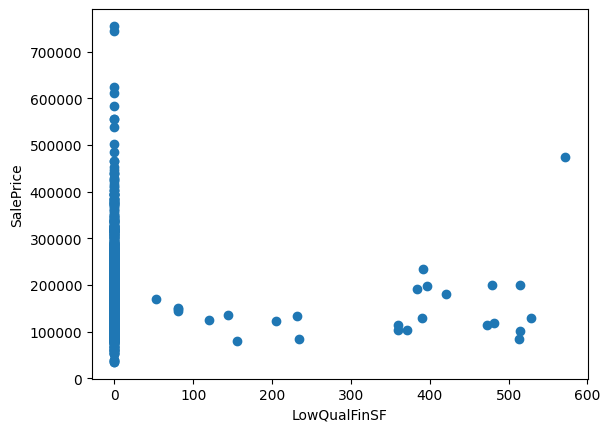

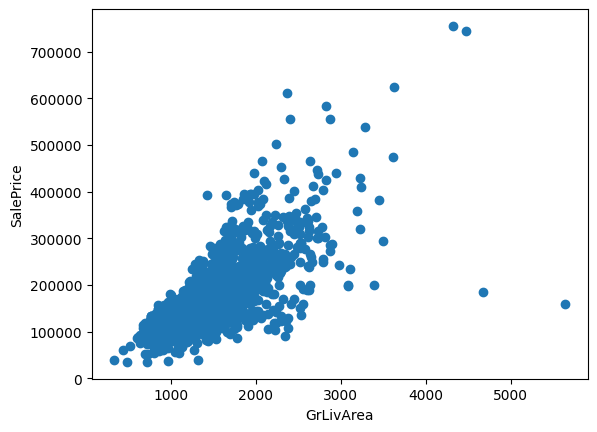

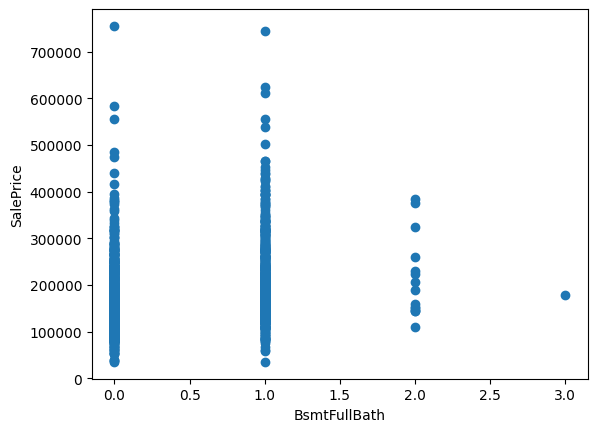

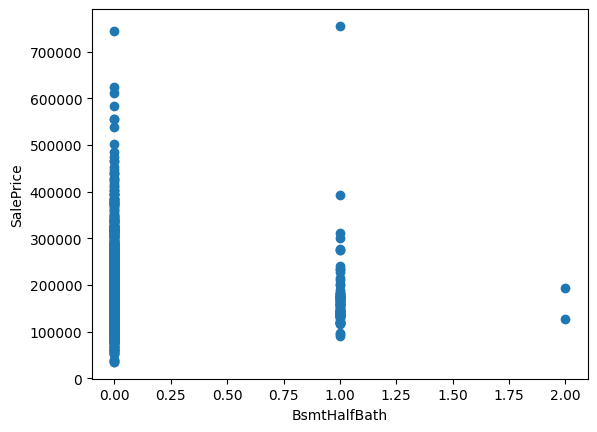

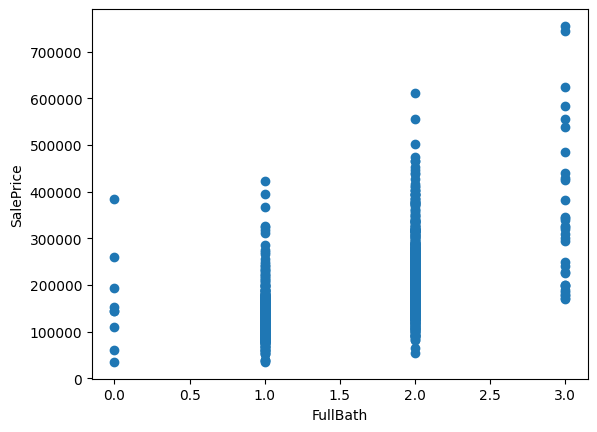

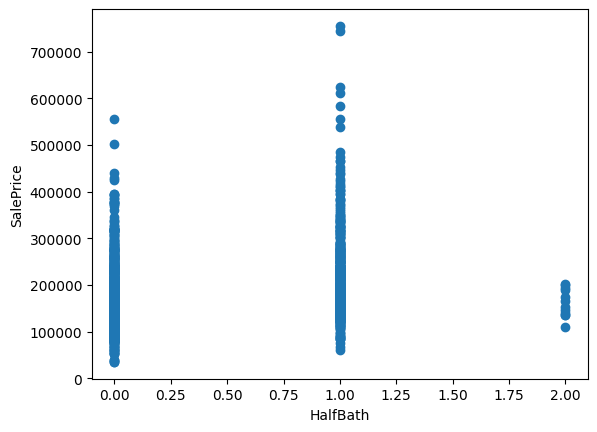

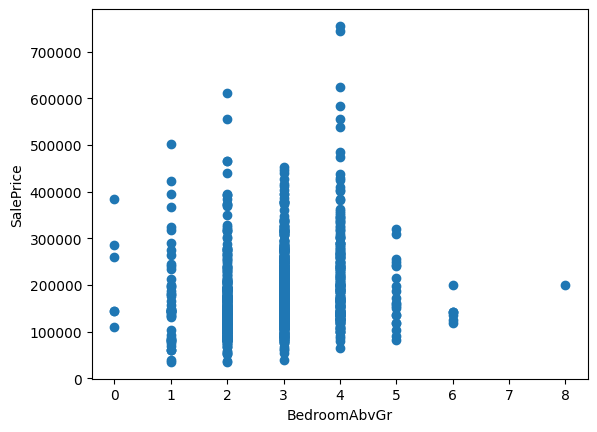

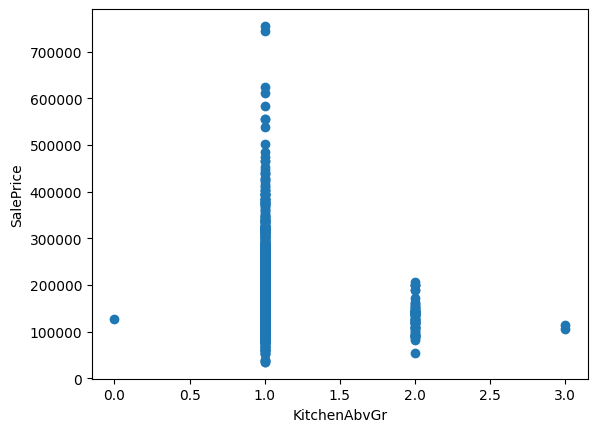

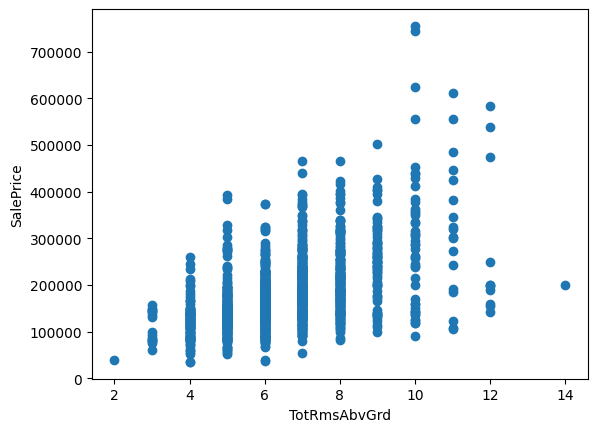

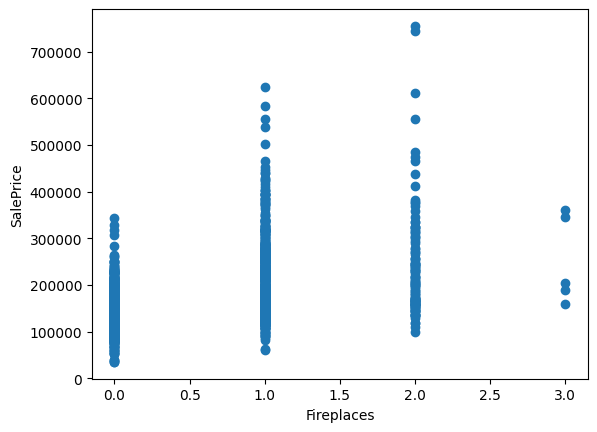

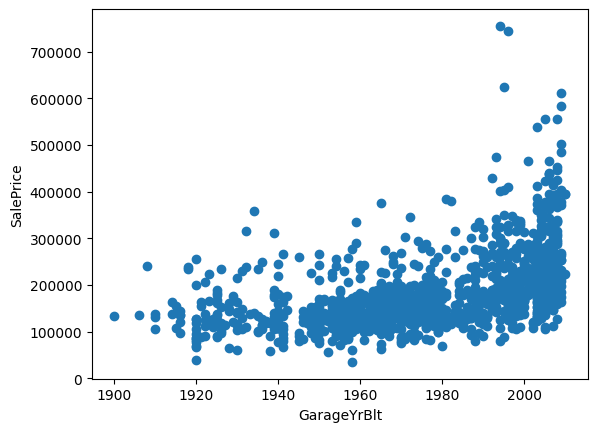

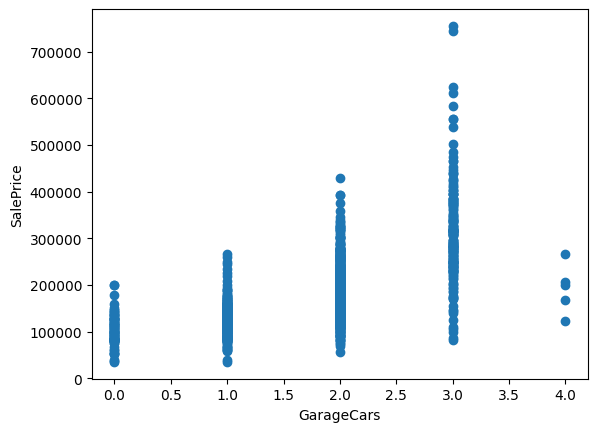

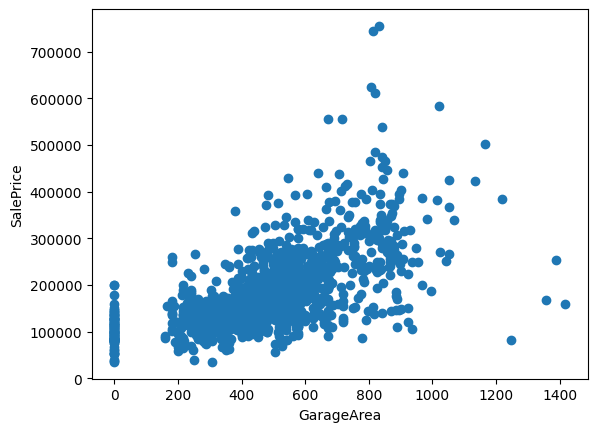

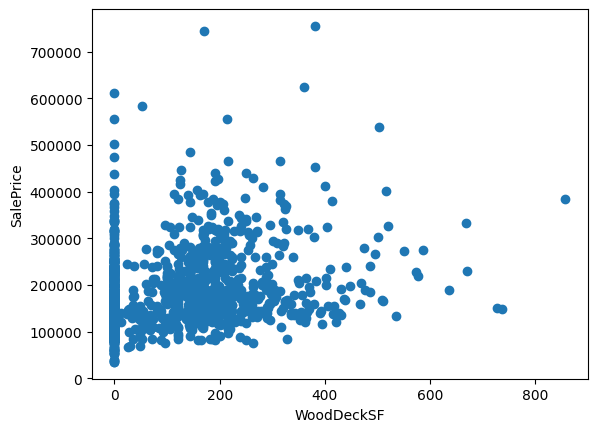

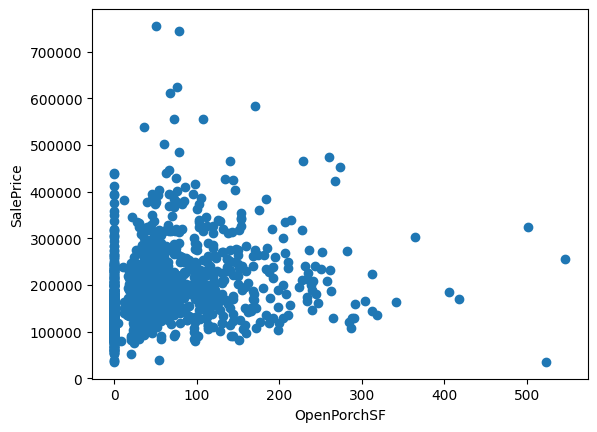

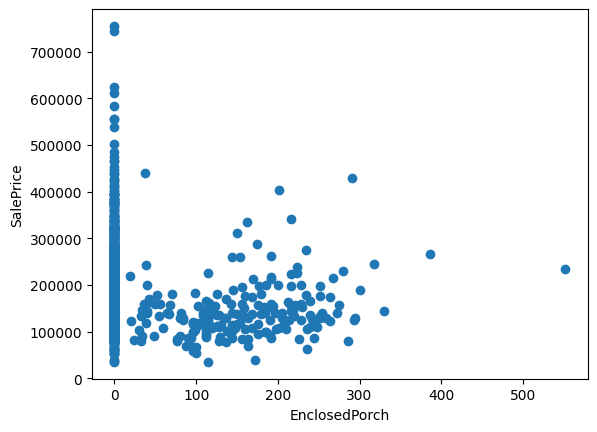

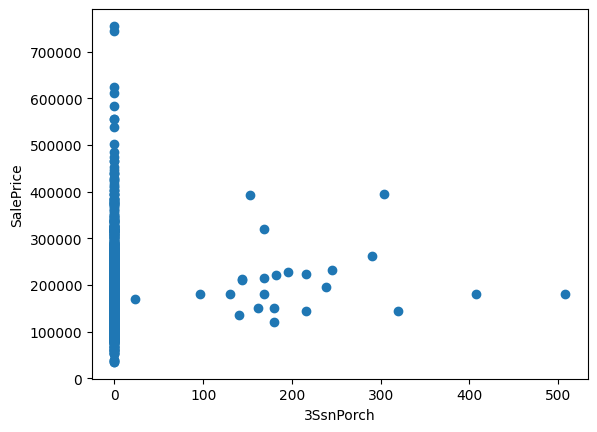

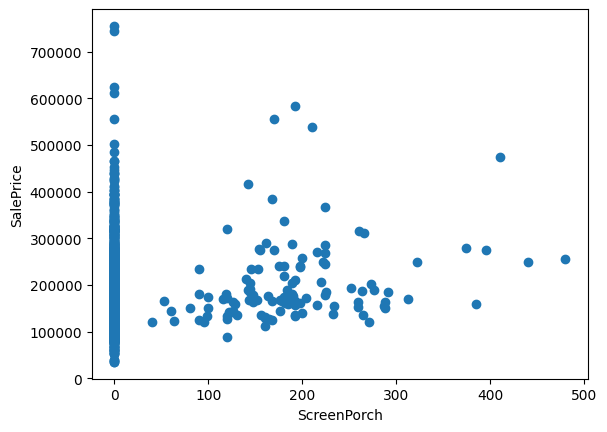

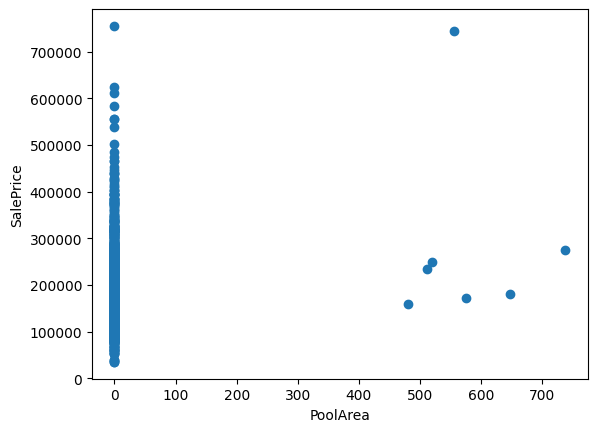

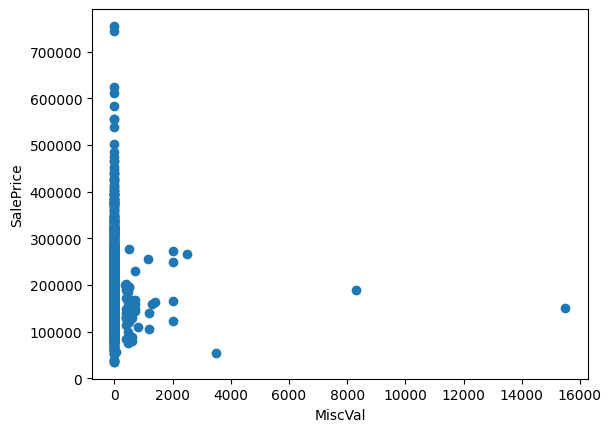

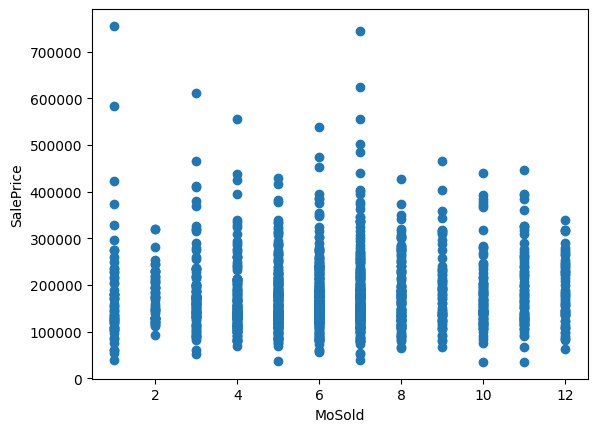

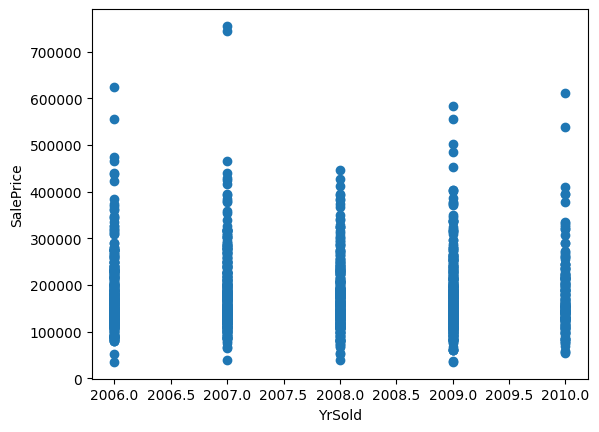

In [7]:
# the plot_lin functions plots a scatterplot of each independent feature(X) to the dependent feature ('Sale_Price')
# this is done so as to visually detect outiers
from swiftmltoolz import plot_lin
plot_lin(train_df,column_names=num_columns[1:-1], y="SalePrice")

In [8]:
# From the scatterplots above, the followinf ids were detected as outliers and thus are stored in the ids_to_drop 
# variable
ids_to_drop = [935,1299,250,314,336,707,524,379,1183, 692, 186,314,298,186,739,598,955,636,441,810,1062,496,198]


In [9]:
# Ids from the  ids_to_drop  variable are filtered from the dataset.
# the count drops from 1460 to 1439

train_df = train_df[train_df.Id.isin(ids_to_drop) == False]
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,...,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,...,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,...,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,.

### 3. Treating NaN Values

In [10]:
# Computing the count of NaN values per feature
train_df.isna().sum().sort_values(ascending=False)

PoolQC           1435
MiscFeature      1388
Alley            1350
Fence            1163
MasVnrType        861
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

##### From above, [PoolQC,MiscFeature,Alley,Fence] feature has the highest no of NaN values. These will likely be dropped. Based on the documentation, we shall fill all NaN values with the appropriate values.

##### For the next step, the unique values present in the feature will be visualized and then the NaN valued will be filled with the appropriate values, "No" in the case of Masonry veneer type to indicate houses with no Masonry veneer installed

##### * MasVnrType (type of Masonry Veneer Installed)

In [11]:
train_df["MasVnrType"].unique()

<StringArray>
['BrkFace', nan, 'Stone', 'BrkCmn']
Length: 4, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\580448986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="MasVnrType",y="SalePrice",kind="box",palette="hls")


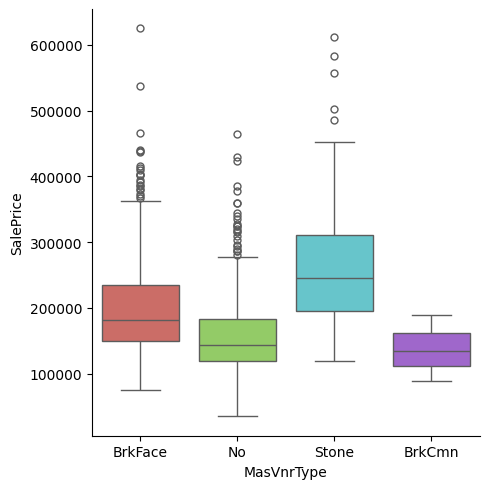

In [12]:
train_df["MasVnrType"] = train_df["MasVnrType"].fillna("No")
test_df["MasVnrType"] = test_df["MasVnrType"].fillna("No")
sns.catplot(data=train_df,x="MasVnrType",y="SalePrice",kind="box",palette="hls")

##### * MasVnrArea (Masonry veneer area in square feet)

In [13]:
# Here this is filled with 0 indicating 0 squarefeet for Houses wth no Masonry Veneer installed
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

##### * FireplaceQu (Fireplace Quality)

In [14]:
train_df["FireplaceQu"].unique()

<StringArray>
[nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po']
Length: 6, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\3354388345.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="FireplaceQu",y="SalePrice",kind="box",palette="hls")


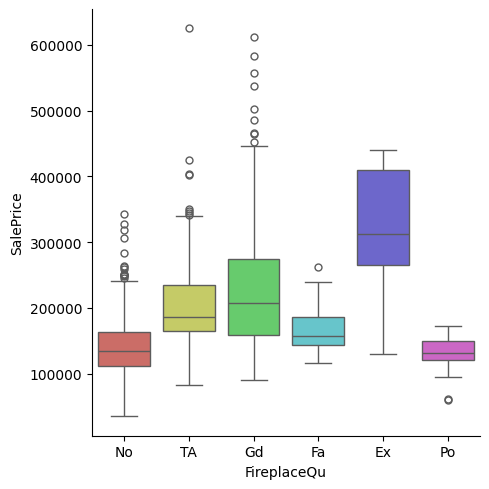

In [15]:
# filled with "NO", indicating no fireplace
train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna("No")
test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("No")
sns.catplot(data=train_df,x="FireplaceQu",y="SalePrice",kind="box",palette="hls")

##### * LotFrontage (Linear feet of street connected to property)

In [16]:
# filled  with 0 indicating 0 squarefeet
train_df["LotFrontage"] = train_df["LotFrontage"].fillna(0)
test_df["LotFrontage"] = test_df["LotFrontage"].fillna(0)

##### * GarageCond (Condition of Garage )

In [17]:
train_df["GarageCond"].unique()

<StringArray>
['TA', 'Fa', nan, 'Gd', 'Po', 'Ex']
Length: 6, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\2272425876.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="GarageCond",y="SalePrice",kind="box",palette="hls")


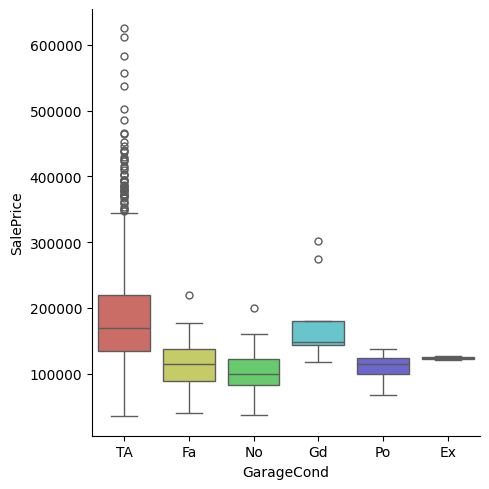

In [18]:
# filled with "No", indicating  the absence of garages in the houses
train_df["GarageCond"] = train_df["GarageCond"].fillna("No")
test_df["GarageCond"] = test_df["GarageCond"].fillna("No")
sns.catplot(data=train_df,x="GarageCond",y="SalePrice",kind="box",palette="hls")

##### * GarageType (type of garage built)

In [19]:
train_df["GarageType"].unique()

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\2319040497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="GarageType",y="SalePrice",kind="box",palette="hls")


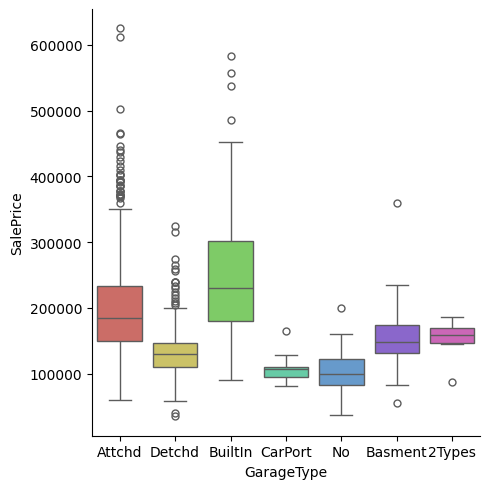

In [20]:
# filled with "No", indicating no garage
train_df["GarageType"] = train_df["GarageType"].fillna("No")
test_df["GarageType"] = test_df["GarageType"].fillna("No")
sns.catplot(data=train_df,x="GarageType",y="SalePrice",kind="box",palette="hls")

##### * GarageFinish (Interior finish of the garage)

In [21]:
train_df["GarageFinish"].unique()

<StringArray>
['RFn', 'Unf', 'Fin', nan]
Length: 4, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\1308499603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="GarageFinish",y="SalePrice",kind="box",palette="hls")


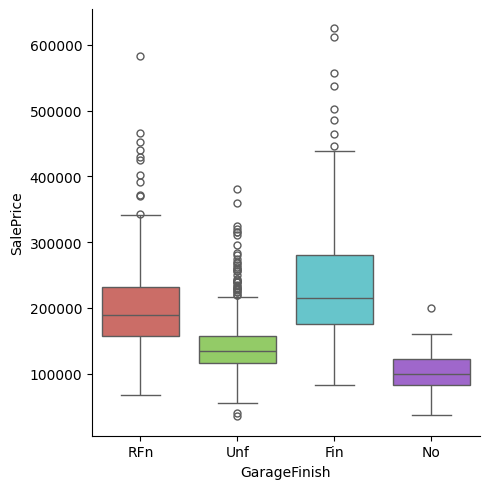

In [22]:
train_df["GarageFinish"] = train_df["GarageFinish"].fillna("No")
test_df["GarageFinish"] = test_df["GarageFinish"].fillna("No")
sns.catplot(data=train_df,x="GarageFinish",y="SalePrice",kind="box",palette="hls")

##### * GarageQual (quality of garage)

In [23]:
train_df["GarageQual"].unique()

<StringArray>
['TA', 'Fa', 'Gd', nan, 'Po', 'Ex']
Length: 6, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\3094677522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="GarageQual",y="SalePrice",kind="box",palette="hls")


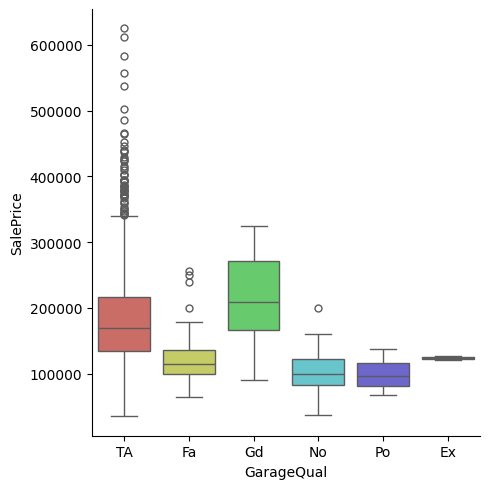

In [24]:
train_df["GarageQual"] = train_df["GarageQual"].fillna("No")
test_df["GarageQual"] = test_df["GarageQual"].fillna("No")
sns.catplot(data=train_df,x="GarageQual",y="SalePrice",kind="box",palette="hls")

##### * BsmtFinType2 (Rating of basement finished area (if multiple types))

In [25]:
train_df["BsmtFinType2"].unique()

<StringArray>
['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 7, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\3197751545.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="BsmtFinType2",y="SalePrice",kind="box",palette="hls")


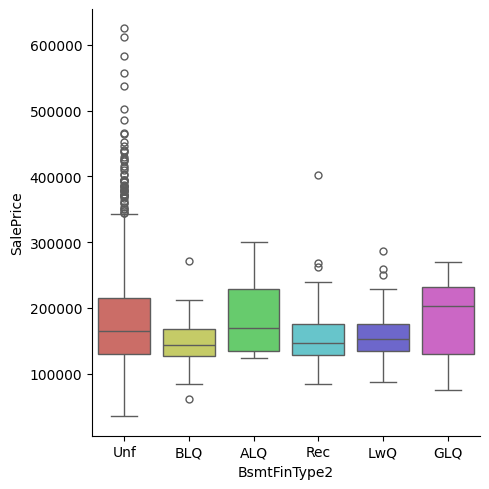

In [26]:
# Here NaN means No basement
# filled with "Unf", indicating Unfinished basement
train_df["BsmtFinType2"] = train_df["BsmtFinType2"].fillna("Unf")
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].fillna("Unf")
sns.catplot(data=train_df,x="BsmtFinType2",y="SalePrice",kind="box",palette="hls")

##### * BsmtExposure (Refers to walkout or garden level walls)

In [27]:
train_df["BsmtExposure"].unique()

<StringArray>
['No', 'Gd', 'Mn', 'Av', nan]
Length: 5, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\2769758534.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="BsmtExposure",y="SalePrice",kind="box",palette="hls")


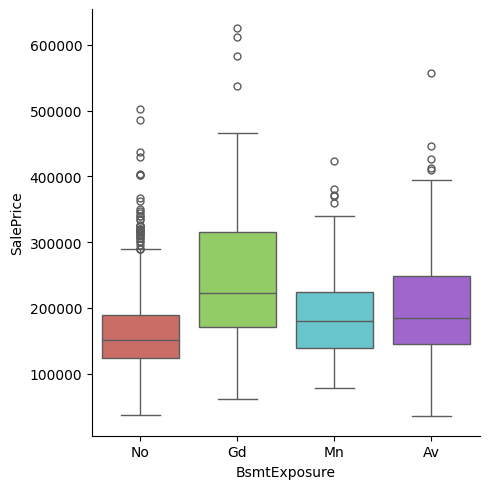

In [28]:
# Here NaN represents no basement
# filled with "No", to indicate no Exposure
train_df["BsmtExposure"] = train_df["BsmtExposure"].fillna("No")
test_df["BsmtExposure"] = test_df["BsmtExposure"].fillna("No")
sns.catplot(data=train_df,x="BsmtExposure",y="SalePrice",kind="box",palette="hls")

##### * BsmtQual (Height of the basement)

In [29]:
train_df["BsmtQual"].unique()

<StringArray>
['Gd', 'TA', 'Ex', nan, 'Fa']
Length: 5, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\2296187015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="BsmtQual",y="SalePrice",kind="box",palette="hls")


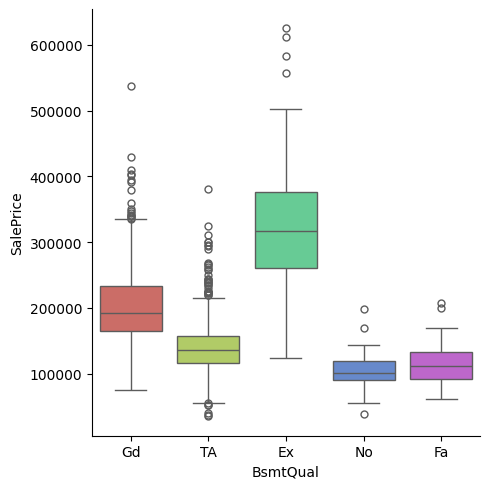

In [30]:
# filled with "No", indicating no basement
train_df["BsmtQual"] = train_df["BsmtQual"].fillna("No")
test_df["BsmtQual"] = test_df["BsmtQual"].fillna("No")
sns.catplot(data=train_df,x="BsmtQual",y="SalePrice",kind="box",palette="hls")

##### * BsmtCond (Condition of Basement)

In [31]:
train_df["BsmtCond"].unique()

<StringArray>
['TA', 'Gd', nan, 'Fa', 'Po']
Length: 5, dtype: str

C:\Users\deoff\AppData\Local\Temp\ipykernel_4208\2726205859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=train_df,x="BsmtCond",y="SalePrice",kind="box",palette="hls")


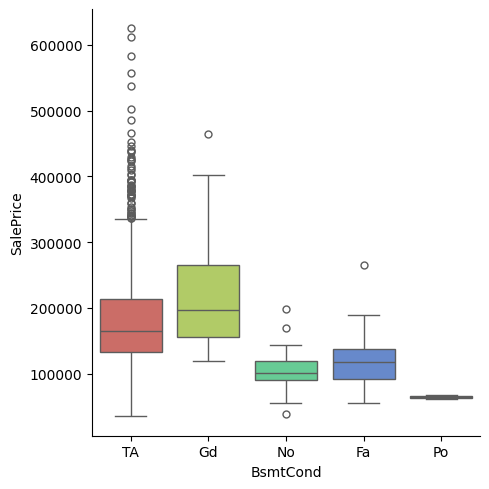

In [32]:
train_df["BsmtCond"] = train_df["BsmtCond"].fillna("No")
test_df["BsmtCond"] = test_df["BsmtCond"].fillna("No")
sns.catplot(data=train_df,x="BsmtCond",y="SalePrice",kind="box",palette="hls")

##### * BsmtFinType1 (Rating of basement finished area)

In [33]:
train_df["BsmtFinType1"].unique()

<StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ']
Length: 7, dtype: str

In [34]:
# here NaN means NO basement
# filled with "Unf", indicating unfinished basement
train_df["BsmtFinType1"] = train_df["BsmtFinType1"].fillna("Unf")
test_df["BsmtFinType1"] = test_df["BsmtFinType1"].fillna("Unf")

##### * MasVnrArea (Masonry veneer area in square feet)

In [35]:
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

##### * Electrical (electrical system)

In [36]:
train_df["Electrical"].value_counts()

Electrical
SBrkr    1316
FuseA      91
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [37]:
train_df["Electrical"] = train_df["Electrical"].fillna("SBrkr")
test_df["Electrical"] = test_df["Electrical"].fillna("SBrkr")

In [38]:
# From context GarageYrBult and YearBuilt(when the house was built) seems  similar. 
# checking the correlation between when garage and house was built
train_df["GarageYrBlt"].corr(train_df.YearBuilt)
# GarageYrBlt will be dropped since both of them appears to be a bit similar

np.float64(0.8280103885885187)

In [39]:
# Dropping features with high NaN values 
# BsmtFinType2 appears to be too similar with BsmtFinType1
# GarageCond seems too similar with GarageQual

columns_to_drop = ["PoolQC","MiscFeature","Alley","Fence","GarageYrBlt","BsmtFinType2","GarageCond"]
train_df.drop(columns=columns_to_drop,inplace=True)
test_df.drop(columns=columns_to_drop,inplace=True)

### 4. Feature Engineering 
##### Creating new features House_age, HouseRemodel_age, totalSF, TotalArea, Totalbaths and TotalPorchSF

In [40]:
train_df["House_age"] = train_df["YrSold"] - train_df["YearBuilt"]
test_df["House_age"] = test_df["YrSold"] - test_df["YearBuilt"]

In [41]:
train_df["HouseRemodel_age"] = train_df["YrSold"] -train_df["YearRemodAdd"]
test_df["HouseRemodel_age"] = test_df["YrSold"] -test_df["YearRemodAdd"]

In [42]:
train_df["totalSF"] = train_df["1stFlrSF"] + train_df["2ndFlrSF"] + train_df["BsmtFinSF1"] +train_df["BsmtFinSF2"]
test_df["totalSF"] = test_df["1stFlrSF"] + test_df["2ndFlrSF"] + test_df["BsmtFinSF1"] +test_df["BsmtFinSF2"]

In [43]:
train_df["TotalArea"] = train_df["GrLivArea"] + train_df["TotalBsmtSF"]
test_df["TotalArea"] = test_df["GrLivArea"] + test_df["TotalBsmtSF"]

In [44]:
train_df["TotalBaths"] = train_df["BsmtFullBath"] + train_df["FullBath"] + 0.5 * train_df["BsmtHalfBath"] +train_df["HalfBath"]
test_df["TotalBaths"] = test_df["BsmtFullBath"] + test_df["FullBath"] + 0.5 * test_df["BsmtHalfBath"] +test_df["HalfBath"]

In [45]:
train_df["TotalPorchSF"] = train_df["WoodDeckSF"] + train_df["OpenPorchSF"] + train_df["EnclosedPorch"] + train_df["3SsnPorch"] + train_df["ScreenPorch"]
test_df["TotalPorchSF"] = test_df["WoodDeckSF"] + test_df["OpenPorchSF"] + test_df["EnclosedPorch"] + test_df["3SsnPorch"] + test_df["ScreenPorch"]

In [46]:
train_df.drop(columns=["Id","YrSold","YearBuilt","YearRemodAdd","1stFlrSF","2ndFlrSF","BsmtFinSF1","BsmtFinSF2","GrLivArea","TotalBsmtSF","BsmtFullBath","FullBath","BsmtHalfBath","HalfBath","WoodDeckSF","OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch"], inplace=True)
test_df.drop(columns=["YrSold","YearBuilt","YearRemodAdd","1stFlrSF","2ndFlrSF","BsmtFinSF1","BsmtFinSF2","GrLivArea","TotalBsmtSF","BsmtFullBath","FullBath","BsmtHalfBath","HalfBath","WoodDeckSF","OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch"], inplace=True)

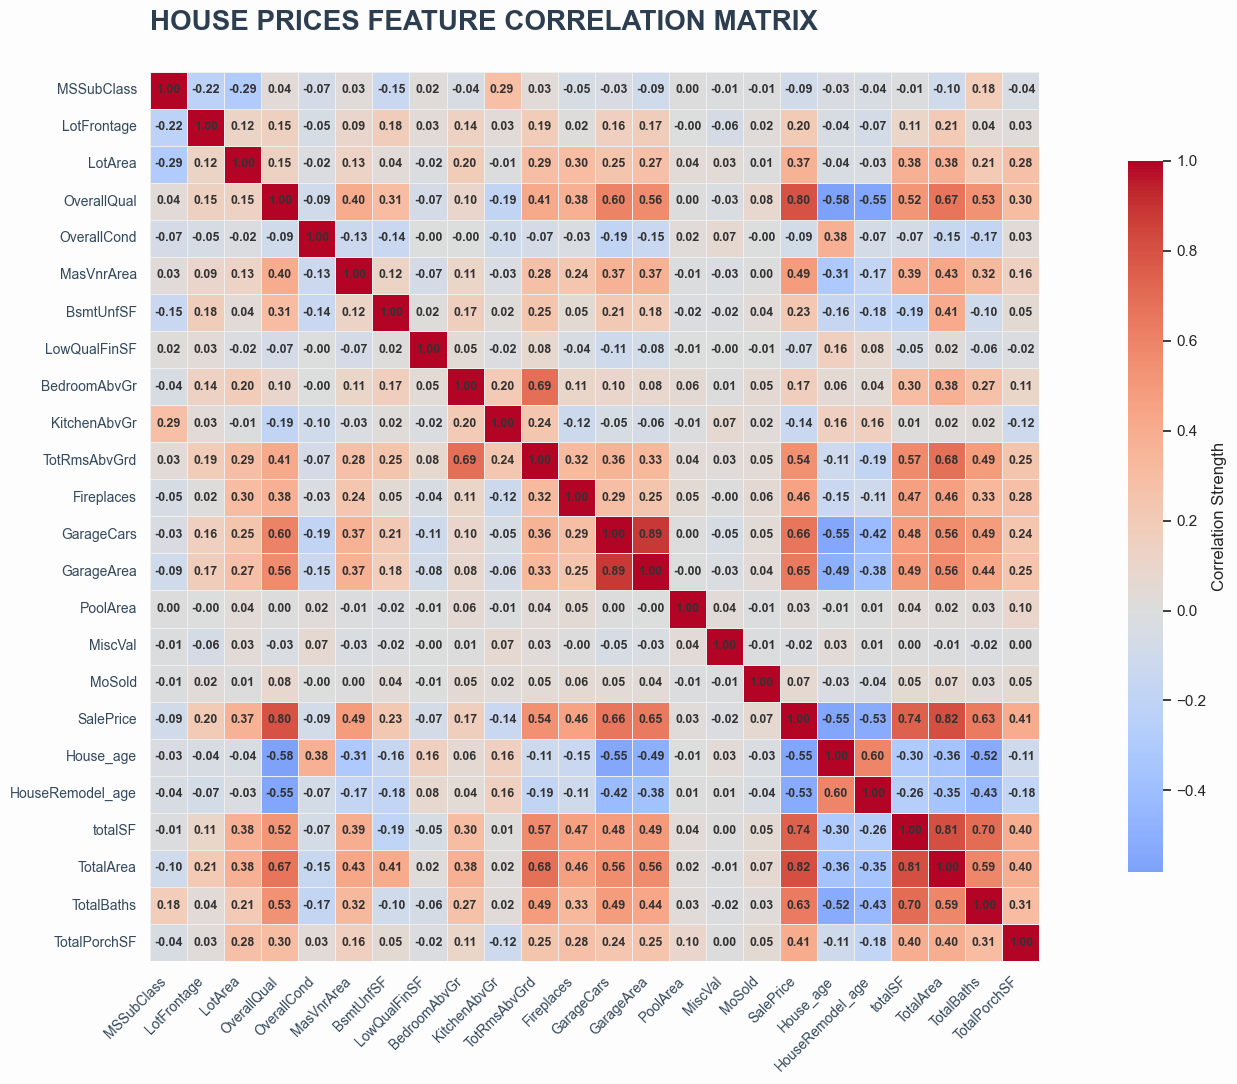

In [47]:
# Checking for some more correlation between features using a heatmap
from swiftmltoolz import plot_corr_heatmap
plot_corr_heatmap(train_df, cmap="coolwarm", title="House Prices Feature Correlation Matrix")

##### From the above heatmap, both [GarageArea and GarageCars], [totalSF and TotalArea] seem to have high correlation. One of feature from each set will be dropped

In [48]:
print(f" Corr between GarageCars and  GarageArea -----> {train_df['GarageArea'].corr(train_df['GarageCars'])}") 
# GarageArea has lower corr with salesPrice
print(f" Corr between totalSF and TotalArea -----> {train_df['totalSF'].corr(train_df['TotalArea'])}") 
# Total Sf has lower corr with SalePrice

 Corr between GarageCars and  GarageArea -----> 0.8867525945865311
 Corr between totalSF and TotalArea -----> 0.8136262606134408


In [49]:
train_df.drop(columns=["GarageArea","totalSF"],inplace = True)
test_df.drop(columns=["GarageArea","totalSF"],inplace = True)

##### Visualizing the SalePrice feature

<Axes: xlabel='SalePrice', ylabel='Count'>

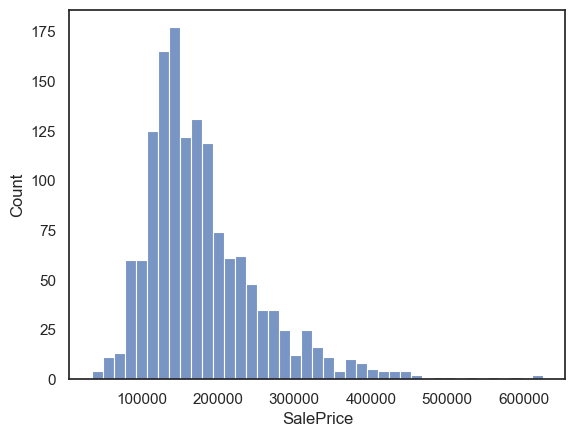

In [50]:
sns.histplot(
    train_df, x= train_df["SalePrice"]
)

In [51]:
# transforming the right skewed SalePrice with np.log1p
# calculating the log(1 + x) for each houseprice in the array acts as a compressor to fix the skewness.
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

<Axes: xlabel='SalePrice', ylabel='Count'>

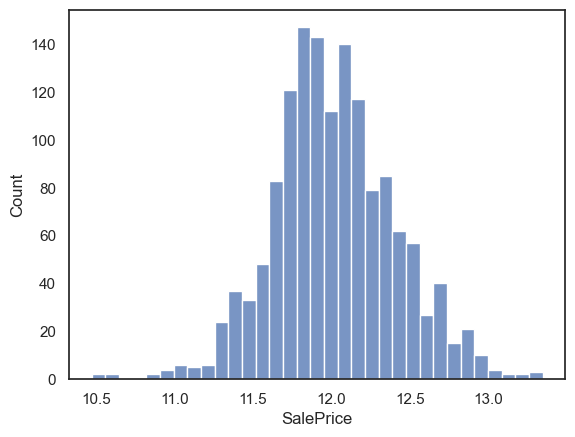

In [52]:
sns.histplot(
    train_df, x= train_df["SalePrice"]
)

### 5. Preprocessing
##### Separating the dataset into categorical(OneHotEncoding, ordinal) and numerical 


In [53]:
print(train_df.dtypes[train_df.dtypes == "str"].count()," -----> no. of features of type str")
print(train_df.dtypes[train_df.dtypes != "str"].count(),"------> no. of  numerical features")

37  -----> no. of features of type str
22 ------> no. of  numerical features


In [54]:
train_df.dtypes[train_df.dtypes == "str"]

MSZoning         str
Street           str
LotShape         str
LandContour      str
Utilities        str
LotConfig        str
LandSlope        str
Neighborhood     str
Condition1       str
Condition2       str
BldgType         str
HouseStyle       str
RoofStyle        str
RoofMatl         str
Exterior1st      str
Exterior2nd      str
MasVnrType       str
ExterQual        str
ExterCond        str
Foundation       str
BsmtQual         str
BsmtCond         str
BsmtExposure     str
BsmtFinType1     str
Heating          str
HeatingQC        str
CentralAir       str
Electrical       str
KitchenQual      str
Functional       str
FireplaceQu      str
GarageType       str
GarageFinish     str
GarageQual       str
PavedDrive       str
SaleType         str
SaleCondition    str
dtype: object

In [55]:
OneHot_cols = ['MSZoning','Street','LotConfig','Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation','Heating','Electrical','GarageType','SaleType','SaleCondition']
Ordinal_cols = ['LotShape','LandContour','LandSlope','ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','HeatingQC','KitchenQual','Functional','FireplaceQu','GarageFinish','GarageQual','PavedDrive','Utilities','CentralAir']


In [56]:
train_df[OneHot_cols]

,MSZoning,Street,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,Electrical,GarageType,SaleType,SaleCondition
0,RL,Pave,Inside,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal
1,RL,Pave,FR2,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,No,CBlock,GasA,SBrkr,Attchd,WD,Normal
2,RL,Pave,Inside,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal
3,RL,Pave,Corner,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,No,BrkTil,GasA,SBrkr,Detchd,WD,Abnorml
4,RL,Pave,FR2,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Inside,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,No,PConc,GasA,SBrkr,Attchd,WD,Normal
1456,RL,Pave,Inside,NWAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,Plywood,Plywood,Stone,CBlock,GasA,SBrkr,Attchd,WD,Normal
1457,RL,Pave,Inside,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,CemntBd,CmentBd,No,Stone,GasA,SBrkr,Attchd,WD,Normal
1458,RL,Pave,Inside,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,MetalSd,MetalSd,No,CBlock,GasA,FuseA,Attchd,WD,Normal


In [57]:
train_df[Ordinal_cols]

,LotShape,LandContour,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,PavedDrive,Utilities,CentralAir
0,Reg,Lvl,Gtl,Gd,TA,Gd,TA,No,GLQ,Ex,Gd,Typ,No,RFn,TA,Y,AllPub,Y
1,Reg,Lvl,Gtl,TA,TA,Gd,TA,Gd,ALQ,Ex,TA,Typ,TA,RFn,TA,Y,AllPub,Y
2,IR1,Lvl,Gtl,Gd,TA,Gd,TA,Mn,GLQ,Ex,Gd,Typ,TA,RFn,TA,Y,AllPub,Y
3,IR1,Lvl,Gtl,TA,TA,TA,Gd,No,ALQ,Gd,Gd,Typ,Gd,Unf,TA,Y,AllPub,Y
4,IR1,Lvl,Gtl,Gd,TA,Gd,TA,Av,GLQ,Ex,Gd,Typ,TA,RFn,TA,Y,AllPub,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,Reg,Lvl,Gtl,TA,TA,Gd,TA,No,Unf,Ex,TA,Typ,TA,RFn,TA,Y,AllPub,Y
1456,Reg,Lvl,Gtl,TA,TA,Gd,TA,No,ALQ,TA,TA,Min1,TA,Unf,TA,Y,AllPub,Y
1457,Reg,Lvl,Gtl,Ex,Gd,TA,Gd,No,GLQ,Ex,Gd,Typ,Gd,RFn,TA,Y,AllPub,Y
1458,Reg,Lvl,Gtl,TA,TA,TA,TA,Mn,GLQ,Gd,Gd,Typ,No,Unf,TA,Y,AllPub,Y


In [58]:
num_cols = train_df.select_dtypes(include=['int64','float64'])
num_cols = num_cols.drop(columns=['SalePrice'])

In [59]:
num_cols = num_cols.columns.tolist()
num_cols
#converting num cols to list for later use

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'MasVnrArea',
 'BsmtUnfSF',
 'LowQualFinSF',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'House_age',
 'HouseRemodel_age',
 'TotalArea',
 'TotalBaths',
 'TotalPorchSF']

##### Building Pipelines

In [60]:
num_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy='mean')),
    ("scalar", StandardScaler())
])

In [61]:
OneHot_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy='most_frequent')),
    ("OneHotEncoder", OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [62]:
Ordinal_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy='most_frequent')),
    ("ordinal_encoder", OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

In [63]:
col_trans = ColumnTransformer(transformers=[
    ('num_p',num_pipeline, num_cols),
    ('onehot_p',OneHot_pipeline, OneHot_cols),
    ('ordinal_p',Ordinal_pipeline,Ordinal_cols),
    ], 
    remainder='passthrough', n_jobs= -1
                              )

In [64]:
pipeline = Pipeline(steps=[
    ('preprocessing',col_trans)
])

In [65]:
# separating the data into X and y 
X=train_df.drop("SalePrice", axis=1)
y=train_df["SalePrice"]

In [66]:
# saving column_names for future use
X_column_names = X.columns

In [67]:
X_preprocessed = pipeline.fit_transform(X)

In [68]:
# creating train and test data
X_train,X_test,y_train,y_test = train_test_split(X_preprocessed,y, test_size =0.2, random_state=1)

### 6.  Training / Model Building

##### 1. Linear regression

In [69]:
#linear regression
lr = LinearRegression()
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
y_pred_lr = lr.predict(X_test)

##### Metrics for Linear Regression

In [71]:
print(round(mean_squared_error(y_test,y_pred_lr),3), "----> MSE")
scores_lr = cross_val_score(lr,X_preprocessed,y,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
print(round(-scores_lr.mean(),3), "----> Average MSE values using cross_val")
rmse_scores_lr = np.sqrt(-scores_lr)
print(round(rmse_scores_lr.mean(),3),"---> Average RMSE using cross_val")
print(round(scores_lr.std(),3)," ---> STD")

0.018 ----> MSE
0.015 ----> Average MSE values using cross_val
0.12 ---> Average RMSE using cross_val
0.002  ---> STD


##### 2. Random Forest Regressor

In [72]:
rfr = RandomForestRegressor(random_state=13)

In [73]:
param_grid_rfr = {
    "max_depth": [5,10,15],
    "n_estimators": [100,250,500],
    "min_samples_split": [3,5,10]
}

In [74]:
from sklearn.model_selection import KFold
inner_cv = KFold(n_splits = 5, shuffle=True, random_state = 42 )
rfr_cv = GridSearchCV(rfr,param_grid = param_grid_rfr,cv=inner_cv,scoring="neg_mean_squared_error",n_jobs=-1)
outer_cv = KFold(n_splits = 3, shuffle=True, random_state = 42 )

##### Metrics for RandomForestRegressor

In [75]:

scores_rfr_cv = cross_val_score(rfr_cv,X_preprocessed,y,cv=outer_cv,scoring="neg_mean_squared_error",n_jobs=-1)
print(round(-scores_rfr_cv.mean(),3), "----> Average MSE values using cross_val")
rmse_scores_rfr_cv = np.sqrt(-scores_lr)
print(round(rmse_scores_rfr_cv.mean(),3),"---> Average RMSE using cross_val")
print(round(scores_rfr_cv.std(),3)," ---> STD")

0.018 ----> Average MSE values using cross_val
0.12 ---> Average RMSE using cross_val
0.001  ---> STD


In [76]:
rfr_cv.fit(X_train,y_train)
print(rfr_cv.best_params_,"best parameter from randomforestregressor")

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100} best parameter from randomforestregressor


##### 3. XGBRegressor

In [77]:
xgb =XGBRegressor(random_state=13)

In [78]:
param_grid_xgb = {
    "learning_rate": [0.05,0.1,0.2],
    "max_depth": [3],
    "n_estimators": [300],
    "min_child_weight": [1,2,3],
    "gamma": [0,0.1,0.2],
    "subsample": [0.8,0.9,1.0],
    
    "colsample_bytree": [0.8,0.9,1.0]
}

In [79]:
inner_cv_xgb = KFold(n_splits = 5, shuffle=True, random_state = 42 )
outer_cv_xgb = KFold(n_splits = 3, shuffle=True, random_state = 42 )
xgb_cv = GridSearchCV(xgb,param_grid = param_grid_xgb,cv=inner_cv_xgb,scoring="neg_mean_squared_error",n_jobs=-1)

##### Metrics for XGBoostRegressor

In [80]:
scores_xgb_cv = cross_val_score(xgb_cv,X_preprocessed,y,cv=outer_cv_xgb,scoring="neg_mean_squared_error",n_jobs=-1)
print(round(-scores_xgb_cv.mean(),3), "----> Average MSE values using cross_val")
rmse_scores_xgb_cv = np.sqrt(-scores_lr)
print(round(rmse_scores_xgb_cv.mean(),3),"---> Average RMSE using cross_val")
print(round(scores_xgb_cv.std(),3)," ---> STD")

0.014 ----> Average MSE values using cross_val
0.12 ---> Average RMSE using cross_val
0.002  ---> STD


In [81]:
xgb_cv.fit(X_train,y_train)
print(xgb_cv.best_params_,"best parameter from xgb")
print(round(-1 * xgb_cv.best_score_,3), "----> MSE")

{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8} best parameter from xgb
0.013 ----> MSE


#### 4. Ridge

In [82]:
ridge = Ridge()

In [83]:
param_grid_ridge = {
    "alpha": [0.05,0.1,1,3,5,10],
    "solver": ["auto","svd",'cholesky',"lsqr","sparse_cg","sag"],
}

In [84]:
inner_cv_ridge = KFold(n_splits = 5, shuffle=True, random_state = 42 )
outer_cv_ridge = KFold(n_splits = 3, shuffle=True, random_state = 42 )
ridge_cv = GridSearchCV(ridge,param_grid = param_grid_ridge,cv=inner_cv_ridge,scoring="neg_mean_squared_error",n_jobs=-1)

##### Metrics for Ridge

In [85]:
scores_ridge_cv = cross_val_score(ridge_cv,X_preprocessed,y,cv=outer_cv_ridge,scoring="neg_mean_squared_error",n_jobs=-1)
print(round(-scores_ridge_cv.mean(),3), "----> Average MSE values using cross_val")
rmse_scores_ridge_cv = np.sqrt(-scores_lr)
print(round(rmse_scores_ridge_cv.mean(),3),"---> Average RMSE using cross_val")
print(round(scores_ridge_cv.std(),3)," ---> STD")

0.013 ----> Average MSE values using cross_val
0.12 ---> Average RMSE using cross_val
0.003  ---> STD


In [86]:
ridge_cv.fit(X_train,y_train)
print(round(-1 * ridge_cv.best_score_,3), "----> MSE")
print(ridge_cv.best_params_,"best parameter from ridge")

0.012 ----> MSE
{'alpha': 10, 'solver': 'auto'} best parameter from ridge


#### 5. SVR

In [87]:
from sklearn.svm import SVR
svr = SVR(kernel='poly', degree=3, C=0.1, gamma='scale')
svr = svr.fit(X_train,y_train)
print(svr.score(X_train,y_train))
print(svr.score(X_test,y_test))
np.sqrt(mean_squared_error(y_test,svr.predict(X_test)))

0.9076317198039962
0.8841691897473035


np.float64(0.13236199672874757)

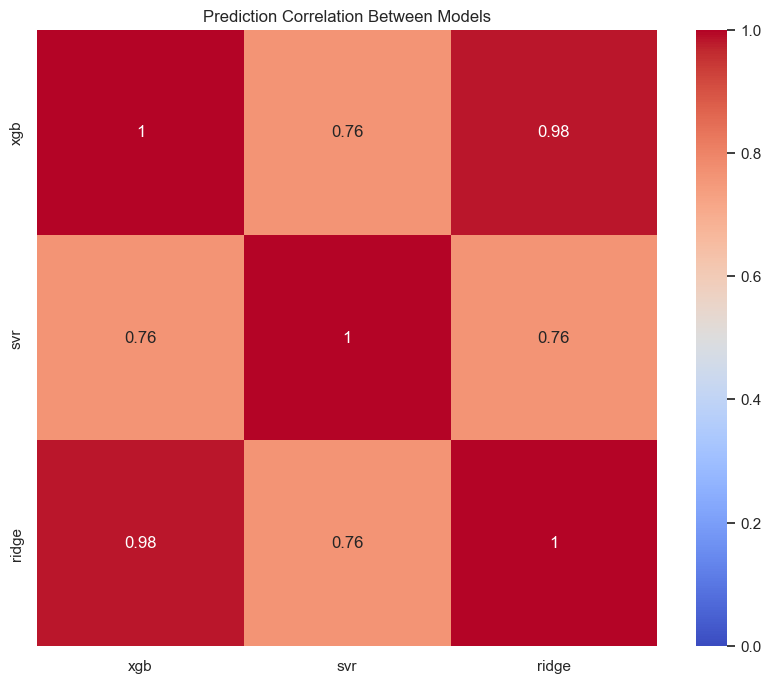

In [88]:
from swiftmltoolz import plot_model_pred_corr
model_list = [
    ("xgb", XGBRegressor(colsample_bytree = 1.0, gamma = 0, learning_rate= 0.1,max_depth= 3, min_child_weight= 3, n_estimators=300,subsample= 0.8)),
    ("svr", SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)),
    ("ridge", Ridge(alpha= 10, solver= 'auto'))
]
plot_model_pred_corr(model_list,X_preprocessed,y,cv=5)

##### 6. Voting Regressor

In [89]:
from sklearn.linear_model import Lasso
vot_reg = VotingRegressor(estimators= [
    ("svr", SVR(kernel='poly', degree=3, C=1, gamma='scale')),
    ("xgb", XGBRegressor(colsample_bytree = 1.0, gamma = 0, learning_rate= 0.1,max_depth= 3, min_child_weight= 3, n_estimators=300,subsample= 0.8)),
    ("ridge", Ridge(alpha= 20, solver= 'auto'))
],weights=[1,2,3])

In [90]:
vot_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svr', ...), ('xgb', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[1, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1


##### Metrics for Voting Regressor


In [91]:
scores_vot = cross_val_score(vot_reg,X_preprocessed,y,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
rmse_scores_vot = np.sqrt(-scores_vot)#converting back to positive
print(rmse_scores_vot.mean()," ----> Average RMSE")
print(round(rmse_scores_vot.std(),3),"std")

0.10876809237981502  ----> Average RMSE
0.006 std


In [92]:
print(vot_reg.score(X_train,y_train)," ------> Training score")

0.9618226612415467  ------> Training score


In [93]:
print(vot_reg.score(X_test,y_test),"-------->Test Score")

0.9094583892047587 -------->Test Score


#### From the training and test scores above, it is clear that the model is overfitting, at this point more data would help in dealing with better generalization on test data.

##### Prediction Error Plot


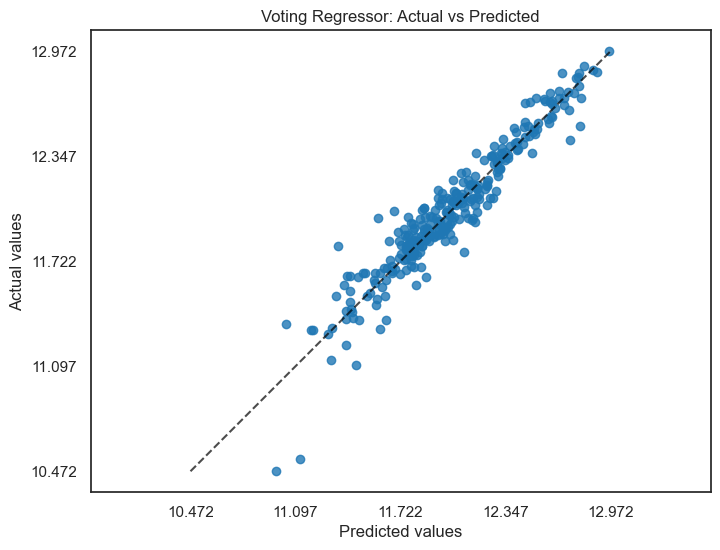

In [94]:
from sklearn.metrics import PredictionErrorDisplay
fig,ax = plt.subplots(figsize=(8,6))
PredictionErrorDisplay.from_predictions(y_test,vot_reg.predict(X_test),kind="actual_vs_predicted",ax=ax)
plt.title("Voting Regressor: Actual vs Predicted")
plt.show()

##### 7. Stacking Regressor

In [95]:

from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold
rkf = RepeatedKFold(n_splits=5,n_repeats=3, random_state=1)
estimators = [
    ("xgb", XGBRegressor(colsample_bytree = 1.0, gamma = 0, learning_rate= 0.1,max_depth= 3, min_child_weight= 3, n_estimators=300,subsample= 0.8,reg_lambda= 15)),
    ("svr", SVR(kernel='poly', degree=3, C=0.1, gamma='scale')),
    ("ridge", Ridge(alpha=30))
   
]


In [96]:
from sklearn.ensemble import StackingRegressor

stack_reg = StackingRegressor(
    estimators = estimators,
    final_estimator=LassoCV(cv = rkf, random_state=42),cv=5, passthrough=False
   
)

In [97]:
stack_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('xgb', ...), ('svr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LassoCV(cv=Re...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [98]:
scores_stack = cross_val_score(stack_reg,X_preprocessed,y,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
rmse_scores_stack = np.sqrt(-scores_stack)#converting back to positive
print(rmse_scores_stack,"scores for every fold")
print(rmse_scores_stack.mean(),"Average score")
print(round(rmse_scores_stack.std(),3),"std")

[0.10571744 0.11005065 0.11913174 0.10671942 0.10672514] scores for every fold
0.10966887609682426 Average score
0.005 std


In [99]:
print(stack_reg.score(X_train,y_train),"-----> Training score")
print(stack_reg.score(X_test,y_test),"-----> Training score")

0.9552074258511809 -----> Training score
0.9074779646775901 -----> Training score


##### Plotting Prediction Error Plot

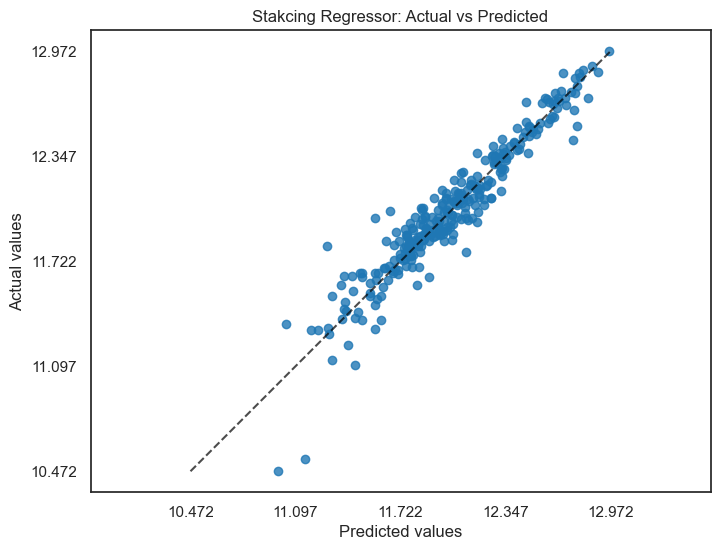

In [ ]:
from sklearn.metrics import PredictionErrorDisplay
fig,ax = plt.subplots(figsize=(8,6))
PredictionErrorDisplay.from_predictions(y_test,stack_reg.predict(X_test),kind="actual_vs_predicted",ax=ax)
plt.title("Stacking Regressor: Actual vs Predicted")
plt.show()

#### Performance Table

In [109]:
performance_df = pd.DataFrame( {
    "models": ["Linear Regression","Random Forest Regressor","XGBoost Regressor","Ridge Regression","Voting Regressor","Stacking Regressor"],
    "Average RMSE": [rmse_scores_lr.mean(),rmse_scores_rfr_cv.mean(),rmse_scores_xgb_cv.mean(),rmse_scores_ridge_cv.mean(),rmse_scores_vot.mean(),rmse_scores_stack.mean()] ,
    "Kaggle Score": [None,None,None,None,0.13366,0.13036]   
}
)
performance_df

,models,Average RMSE,Kaggle Score
0,Linear Regression,0.120240,NaN
1,Random Forest Regressor,0.120240,NaN
2,XGBoost Regressor,0.120240,NaN
3,Ridge Regression,0.120240,NaN
4,Voting Regressor,0.108768,0.13366
5,Stacking Regressor,0.109669,0.13036


##  Preparing Kaggle_Predictions_File

In [108]:
test_preprocessed = pipeline.transform(test_df)
final_model = vot_reg
predictions = np.expm1(final_model.predict(test_preprocessed))
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions
})
submission.to_csv('house_prices_predicitions_Votgregressor.csv',index=False)


##### Conclusion: presently the Stacking Regressor Model makes predictions that are on average within ~ 13.04 percent of the actual prices of the houses. The ~0.02 difference between the local and kaggle rmse scores stems from an apparent optimum generalization to the test data which can be further improved by futher hyperparameter tuning and further feature engineering.